<a href="https://colab.research.google.com/github/Owusuk/Projects/blob/main/JPMorganQuant.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

%matplotlib inline
sns.set_style('darkgrid')
sns.set_palette('rainbow')
sns.set_palette('Set2')

In [2]:
from google.colab import files
uploaded = files.upload()

Saving Nat_Gas.csv to Nat_Gas.csv


In [3]:
Nat_Gas = pd.read_csv('Nat_Gas.csv')
Nat_Gas

,Dates,Prices
0,10/31/20,10.10
1,11/30/20,10.30
2,12/31/20,11.00
3,1/31/21,10.90
4,2/28/21,10.90
5,3/31/21,10.90
6,4/30/21,10.40
7,5/31/21,9.84
8,6/30/21,10.00
9,7/31/21,10.10


In [4]:
Nat_Gas.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48 entries, 0 to 47
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Dates   48 non-null     object 
 1   Prices  48 non-null     float64
dtypes: float64(1), object(1)
memory usage: 900.0+ bytes


In [5]:
Nat_Gas.describe()

,Prices
count,48.000000
mean,11.207083
std,0.757897
min,9.840000
25%,10.650000
50%,11.300000
75%,11.625000
max,12.800000


In [19]:
#@title Line Chart

Line_plot = px.line(Nat_Gas, x='Dates', y='Prices')
Line_plot.show()

In [33]:
!pip install tools

  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.1/99.1 kB 5.4 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for tools: filename=tools-0.1.9-py3-none-any.whl size=46729 sha256=9657eb4bbb12ccb3e5599aaf372532a952c2a6e7975d095c8a9c9e4e4e275f9e
  Stored in directory: /root/.cache/pip/wheels/bc/d8/9d/52ad6058db295741fe0b776c0fcfdb6670036acab59ce4ccfd
  Created wheel for pytils: filename=pytils-0.4.1-py3-none-any.whl size=32876 sha256=6c91f09b6ce2ea8a350a6bd337add264284f1bc078b0a5d97e25cf93de985475
  Stored in directory: /root/.cache/pip/wheels/66/b9/15/482258065bee884b0d43bdc24b424e2cc6bde530e8e1380657
Successfully built tools pytils


In [34]:
#@title Necessary Libs
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from datetime import datetime
import tools

In [12]:
#@title Convert dates column to datetime method

Nat_Gas['Dates'] = pd.to_datetime(Nat_Gas['Dates'], format = '%m/%d/%y')

# Sort by Date to ensure consistency
Nat_Gas = Nat_Gas.sort_values('Dates')

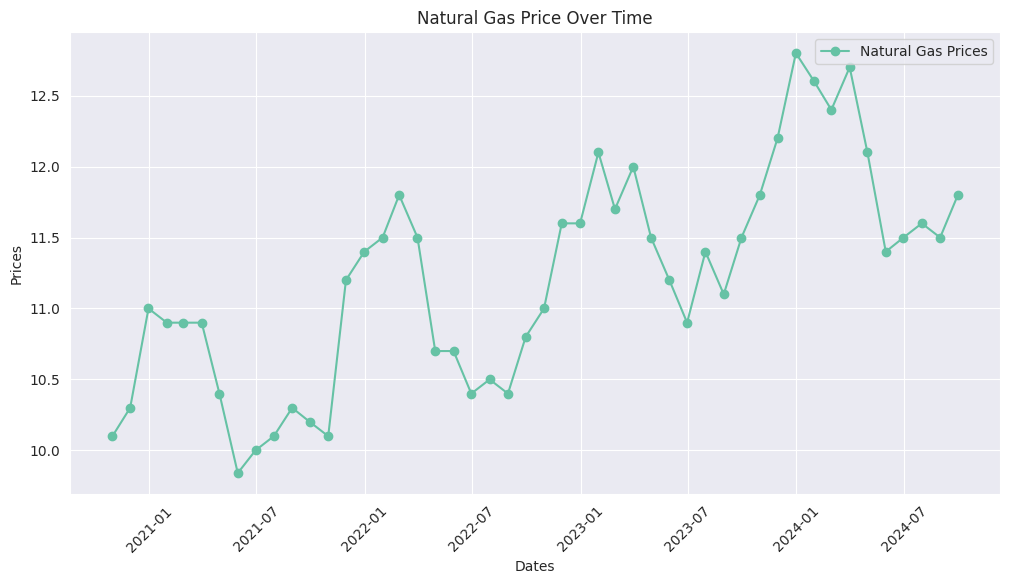

In [20]:
#@title Natural Gas Price Over Time (Line Chart)

plt.figure(figsize=(12, 6))
plt.plot(Nat_Gas['Dates'], Nat_Gas['Prices'], marker='o', linestyle='-', label="Natural Gas Prices")
plt.xlabel('Dates')
plt.ylabel('Prices')
plt.title('Natural Gas Price Over Time')
plt.xticks(rotation=45)
plt.grid(True)
plt.legend()
plt.show()

***The plot above shows the natural gas prices trend over time. We can observe fluctuations and possible seasonal variations with the line plot***

In [21]:
#@title Seasonal Plot

# Monthly information for seasonal analysis

Nat_Gas["Month"] = Nat_Gas["Dates"].dt.month

# Average Prices per month

monthly_avg = Nat_Gas.groupby("Month")["Prices"].mean()

monthly_avg

,Prices
Month,
1,11.775
2,11.700
3,11.775
4,11.175
5,10.785
6,10.700
7,10.900
8,10.825
9,11.075


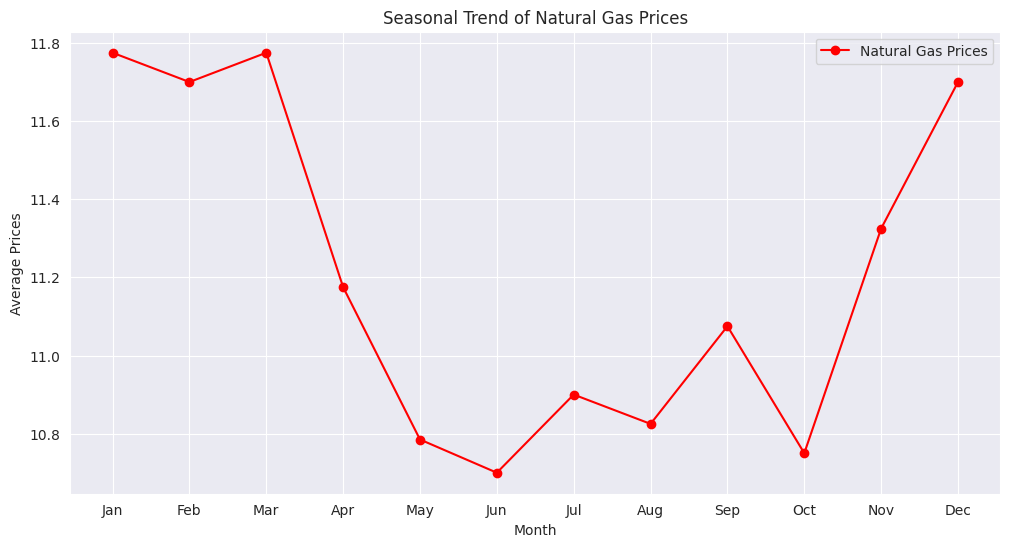

In [22]:
#@title Plot Seasonal Trend

plt.figure(figsize=(12, 6))
plt.plot(monthly_avg.index, monthly_avg.values, marker='o', linestyle='-', color="red", label="Natural Gas Prices")
plt.xlabel('Month')
plt.ylabel('Average Prices')
plt.title("Seasonal Trend of Natural Gas Prices")
plt.xticks(range(1, 13), ["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"])
plt.grid(True)
plt.legend()
plt.show()

***The seasonal analysis shows that natural gas prices tend to be higher in winter months (January, February, & December) and usually lower during summer periods (May - October). This pattern aligns with increased heating demand in colder months and less demand in warmer or hot months***

In [43]:
#@title Extrapolation for an extra year (12 Months)

# Create a function to predict price for any given date
def predict_price(date):
  input_date = pd.to_datetime(date)

  # Past Date
  if input_date in Nat_Gas["Dates"].values:
    actual_price = Nat_Gas.loc[Nat_Gas["Dates"] == input_date, "Prices"].values[0]
    return f"Actual price on {input_date.strftime('%Y-%m-%d')}: {actual_price:.2f}"

  # Future Date or in a Forecast
  if input_date in Nat_Gas["Dates"].values:
    forecasted_price = Nat_Gas.loc[Nat_Gas["Dates"] == input_date, "Prices"].values[0]
    return f"Forecasted price on {input_date.strftime('%Y-%m-%d')}: {forecasted_price:.2f}"

  return "Date is outside the available data range."

# Example usage:
predict_price("2024-05-31")

'Actual price on 2024-05-31: 11.40'

In [30]:
#@title Using Exponential Smoothing for Forecast (y = a + bx)

# Fit the Exponential Smoothing model

model = ExponentialSmoothing(Nat_Gas["Prices"], trend="add", seasonal="add", seasonal_periods=12)
fit = model.fit()

# Forecast for next 12 months

forecast_periods = 12
forecast_dates = pd.date_range(start=Nat_Gas["Dates"].iloc[-1] + pd.DateOffset(months=1), periods=forecast_periods, freq="ME")
forecast_prices = fit.forecast(forecast_periods)

In [31]:
# Forecast DataFrame
forecast_df = pd.DataFrame({"Dates": forecast_dates, "Forecasted Prices": forecast_prices.values})
forecast_df.set_index("Dates", inplace=True)
forecast_df

,Forecasted Prices
Dates,
2024-10-31,12.103782
2024-11-30,12.678810
2024-12-31,13.053791
2025-01-31,13.128799
2025-02-28,13.053792
2025-03-31,13.128793
2025-04-30,12.528778
2025-05-31,12.138793
2025-06-30,12.053780


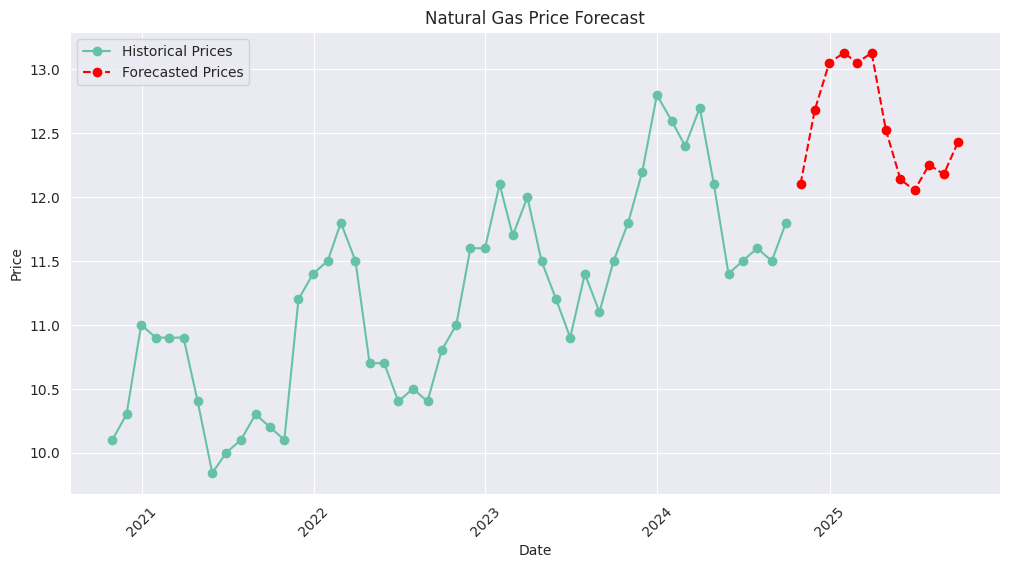

Natural Gas Price Forecast: forecast_df


,Forecasted Prices
Dates,
2024-10-31,12.103782
2024-11-30,12.678810
2024-12-31,13.053791
2025-01-31,13.128799
2025-02-28,13.053792
2025-03-31,13.128793
2025-04-30,12.528778
2025-05-31,12.138793
2025-06-30,12.053780


In [38]:
# Plot historical prices against forecasted prices

plt.figure(figsize=(12, 6))
plt.plot(Nat_Gas["Dates"], Nat_Gas["Prices"], marker='o', linestyle='-', label='Historical Prices')
plt.plot(forecast_dates, forecast_prices, marker='o', linestyle='--', color='red', label='Forecasted Prices')
plt.xlabel("Date")
plt.ylabel("Price")
plt.title("Natural Gas Price Forecast")
plt.xticks(rotation=45)
plt.grid(True)
plt.legend()
plt.show()


# Print a message to identify the DataFrame
print(f"Natural Gas Price Forecast: forecast_df")

forecast_df

***The forecast trends feloows same or similar trajectory as seasonal analysis***